**import packages**


In [70]:

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GroupShuffleSplit

In [74]:
ddos_dataset_df = pd.read_csv("ddos_dataset.csv", low_memory = False)
ddos_dataset_df['label'] = pd.Categorical(ddos_dataset_df['label']).codes #TODO remove when added to pre process
X = ddos_dataset_df.drop(columns=['label'])
y = ddos_dataset_df[['label']]

"""
#for split for per src_ip
dataset_df = df.groupby('src_ip').agg(
    packets_number = pd.NamedAgg(column='packets', aggfunc='count'),
    dst_port = pd.NamedAgg(column='dst_port', aggfunc='nunique'),
    protocols = pd.NamedAgg(column='proto', aggfunc='nunique'),
    dst_ip = pd.NamedAgg(column='dst_ip', aggfunc='nunique'),
    dst_port_min = pd.NamedAgg(column='dst_port', aggfunc='min'),
    dst_port_max = pd.NamedAgg(column='dst_port', aggfunc='max'),
    dst_port_mean = pd.NamedAgg(column='dst_port', aggfunc='mean'),
    dst_port_std = pd.NamedAgg(column='dst_port', aggfunc='std'),
    pck_len_min = pd.NamedAgg(column='pck_len', aggfunc='min'),
    pck_len_max = pd.NamedAgg(column='pck_len', aggfunc='max'),
    pck_len_mean = pd.NamedAgg(column='pck_len', aggfunc='mean'),
    pck_len_std = pd.NamedAgg(column='pck_len', aggfunc='std'),
    ttl_min = pd.NamedAgg(column='ttl', aggfunc='min'),
    ttl_max = pd.NamedAgg(column='ttl', aggfunc='max'),
    ttl_mean = pd.NamedAgg(column='ttl', aggfunc='mean'),
    ttl_std = pd.NamedAgg(column='ttl', aggfunc='std'),
    
).fillna(0)
"""

"\n#for split for per src_ip\ndataset_df = df.groupby('src_ip').agg(\n    packets_number = pd.NamedAgg(column='packets', aggfunc='count'),\n    dst_port = pd.NamedAgg(column='dst_port', aggfunc='nunique'),\n    protocols = pd.NamedAgg(column='proto', aggfunc='nunique'),\n    dst_ip = pd.NamedAgg(column='dst_ip', aggfunc='nunique'),\n    dst_port_min = pd.NamedAgg(column='dst_port', aggfunc='min'),\n    dst_port_max = pd.NamedAgg(column='dst_port', aggfunc='max'),\n    dst_port_mean = pd.NamedAgg(column='dst_port', aggfunc='mean'),\n    dst_port_std = pd.NamedAgg(column='dst_port', aggfunc='std'),\n    pck_len_min = pd.NamedAgg(column='pck_len', aggfunc='min'),\n    pck_len_max = pd.NamedAgg(column='pck_len', aggfunc='max'),\n    pck_len_mean = pd.NamedAgg(column='pck_len', aggfunc='mean'),\n    pck_len_std = pd.NamedAgg(column='pck_len', aggfunc='std'),\n    ttl_min = pd.NamedAgg(column='ttl', aggfunc='min'),\n    ttl_max = pd.NamedAgg(column='ttl', aggfunc='max'),\n    ttl_mean = pd.N

In [75]:
# split train test per flow
# TODO replace naming to fit per flow 


X_train, X_test, y_train, y_test = train_test_split(
    X, # X
    y, # y
    stratify = y, # stratify the dataset based on class labels
    train_size = 0.7, # percentage of training set
    random_state = 15 
)


#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them
cols_to_exclude = ['Flow ID', ' Source IP', ' Destination IP', 'Protocol', ' Timestamp', 'SimillarHTTP','Source Port','Destination Port'] 

# normalize only selected columns
all_features = X_train.columns.tolist()
cols_to_scale = [col for col in all_features if col not in cols_to_exclude]
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])




In [84]:
#TODO validate not sure this is what requested
# should the split be some src ip in train different src ip in dest or litteraly use groupby and then look only at ip level 

# split train test per flow + normalization
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=14)
groups = ddos_dataset_df[' Source IP']
# get splited dataset, iterate one iteration of generaotr
for train_index, test_index in gss.split(X, y, groups=groups):
    X_train_ip, X_test_ip = X.iloc[train_index], X.iloc[test_index]
    y_train_ip, y_test_ip = y.iloc[train_index], y.iloc[test_index]

#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them
cols_to_exclude = ['Flow ID', ' Source IP', ' Destination IP', 'Protocol', ' Timestamp', 'SimillarHTTP','Source Port','Destination Port'] 

# normalize only selected columns
all_features = X_train_ip.columns.tolist()
cols_to_scale = [col for col in all_features if col not in cols_to_exclude]
ip_scaler = StandardScaler()
#X_train_ip[cols_to_scale] = ip_scaler.fit_transform(X_train_ip[cols_to_scale])
#X_test_ip[cols_to_scale] = ip_scaler.transform(X_test_ip[cols_to_scale])


In [90]:
#TODO understand if it's ok to have so many source IP compared to the number of users 25
#cols_to_scale
print(ddos_dataset_df[' Source IP'].unique().size)
print(ddos_dataset_df[' Destination IP'].unique().size)
#GroupShuffleSplit?
train_index
test_index

216
245


array([    0,     2,     3, ..., 64236, 64237, 64238], shape=(58413,))

/tmp/ipykernel_791/2884727688.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette="viridis")


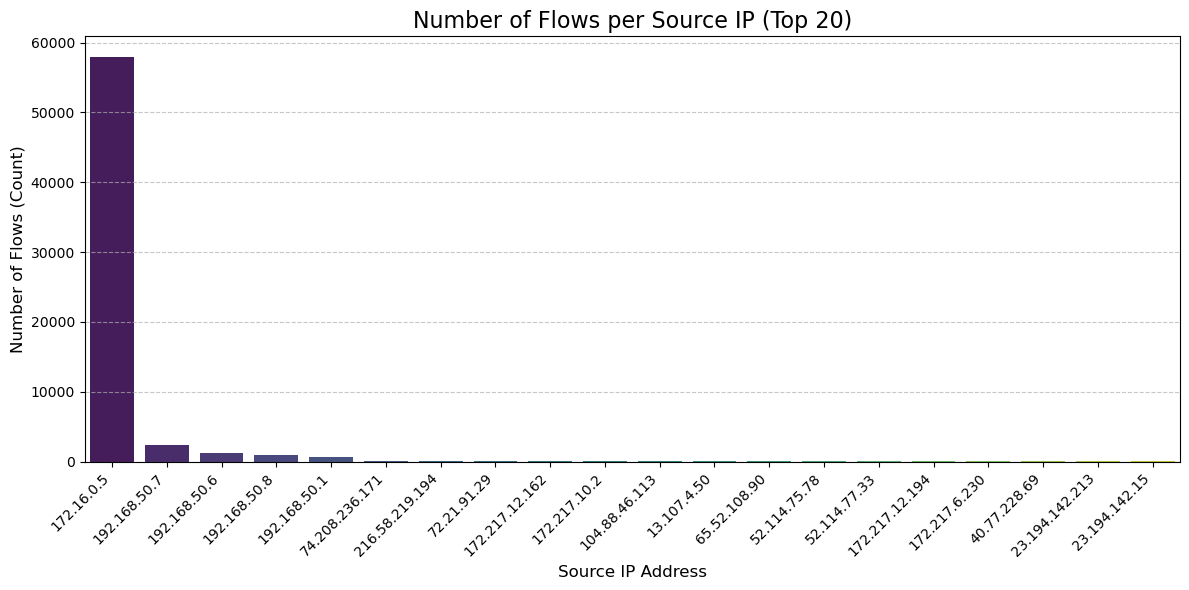

In [88]:
# 1. Aggregate the data (Counting flows per Source IP)
flow_counts = ddos_dataset_df[' Source IP'].value_counts().sort_values(ascending=False)

# 2. Plot the top 20 IPs for readability
top_n = 20
plot_data = flow_counts.head(top_n)

# 3. Create the Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, palette="viridis")
plt.title(f'Number of Flows per Source IP (Top {top_n})', fontsize=16)
plt.xlabel('Source IP Address', fontsize=12)
plt.ylabel('Number of Flows (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()